In [2]:
import pandas as pd

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    "pima-indians-diabetes.data.csv",
    names=columns
)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Rows and Columns:")
print(df.shape)

print("\nDataset Info:")
df.info()

Rows and Columns:
(768, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


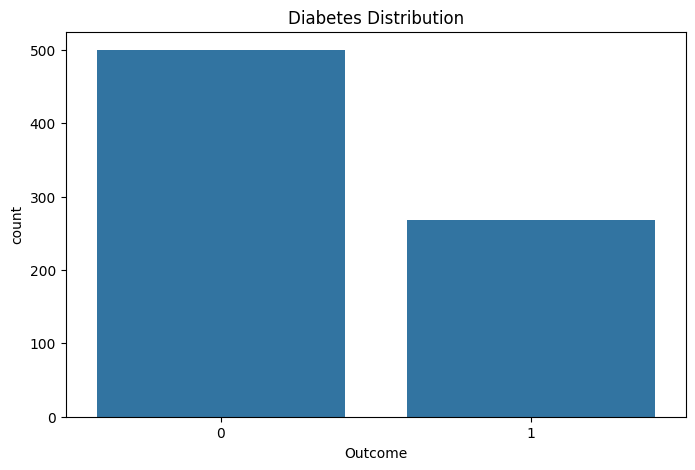

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x=df["Outcome"])

plt.title("Diabetes Distribution")

plt.show()

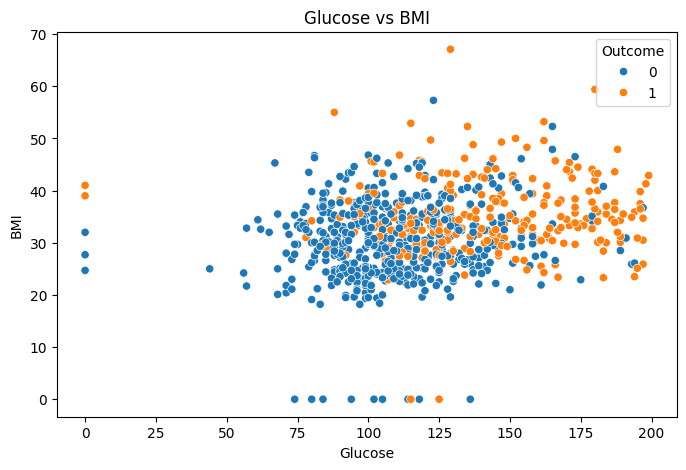

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Glucose"],
    y=df["BMI"],
    hue=df["Outcome"]
)

plt.title("Glucose vs BMI")

plt.show()

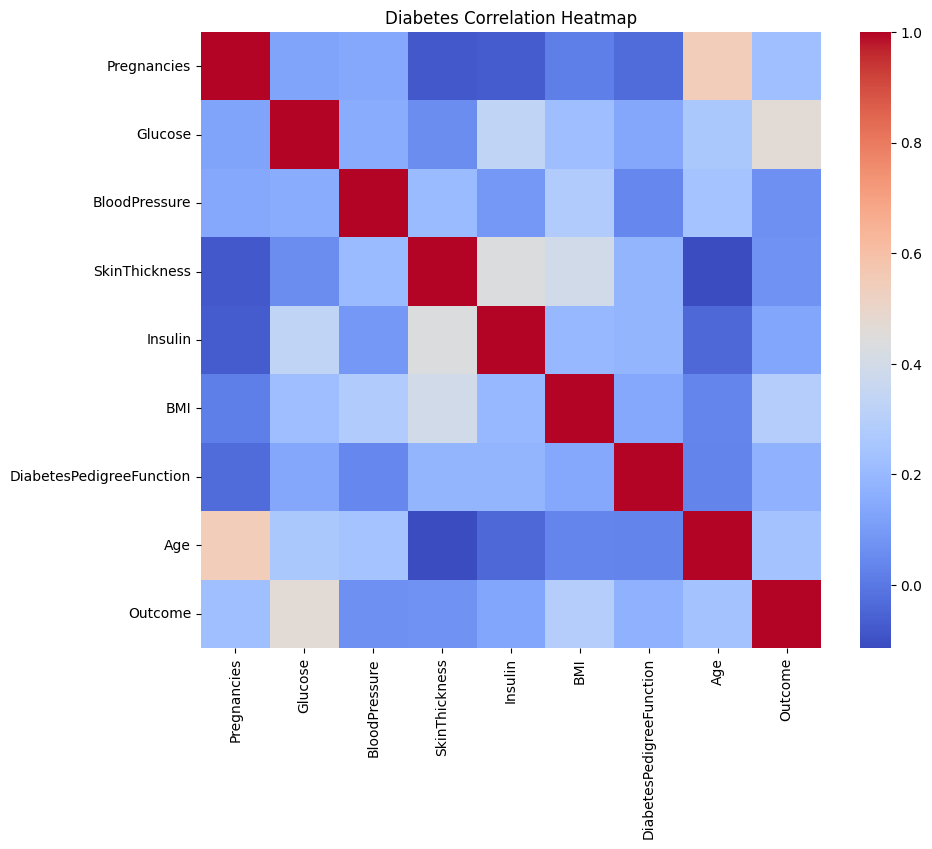

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Diabetes Correlation Heatmap")

plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 75.97 %


In [9]:
sample_patient = [[5,150,80,25,100,32,0.5,45]]

prediction = model.predict(sample_patient)

print("🏥 DIABETES RISK ASSESSMENT")
print("--------------------------")

if prediction[0] == 1:
    print("Risk Level: HIGH")
    print("Recommendation: Consult a Doctor")
else:
    print("Risk Level: LOW")
    print("Recommendation: Maintain Healthy Lifestyle")

🏥 DIABETES RISK ASSESSMENT
--------------------------
Risk Level: HIGH
Recommendation: Consult a Doctor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
